In [1]:
import pandas as pd

df = pd.read_csv("sweden_tourism_weather.csv")

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")

Läsa in soltimmar

SMHI data soltimmar per timme och dag, jag summerar till antal soltimmar per dag.

In [2]:
import pandas as pd

sun = pd.read_csv(
    "data/smhi/sol/stockholm.csv",
    sep=";",
    skiprows=10,
    usecols=[0, 4],
    names=["date", "sun_seconds"],
    header=0,
    encoding="utf-8-sig",
    engine="python"
)

sun.head()

,date,sun_seconds
0,1983-01-01,0
1,1983-01-01,0
2,1983-01-01,0
3,1983-01-01,0
4,1983-01-01,0


In [3]:
daily_sun = (
    sun.groupby("date")["sun_seconds"]
    .sum()
    .reset_index()
)

In [4]:
daily_sun["sun_hours_day"] = (
    daily_sun["sun_seconds"] / 3600
)

In [5]:
daily_sun.head()

,date,sun_seconds,sun_hours_day
0,1983-01-01,0,0.000000
1,1983-01-02,0,0.000000
2,1983-01-03,5154,1.431667
3,1983-01-04,0,0.000000
4,1983-01-05,5154,1.431667


In [6]:
daily_sun["sun_hours_day"].describe()

count    15738.000000
mean         5.095262
std          4.991473
min          0.000000
25%          0.120000
50%          3.903194
75%          8.823750
max         17.905000
Name: sun_hours_day, dtype: float64

<Axes: >

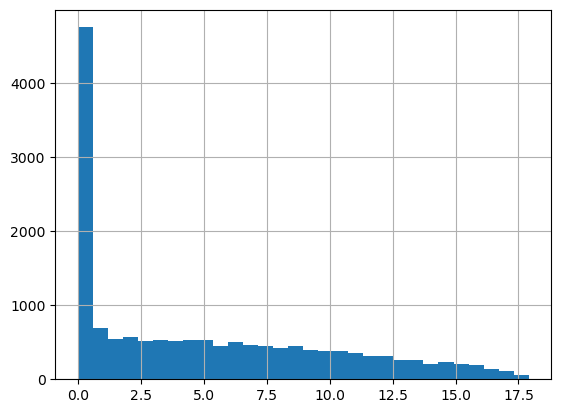

In [7]:
daily_sun["sun_hours_day"].hist(bins=30)

In [8]:
def load_smhi_daily_sun(file_path, region):
    sun = pd.read_csv(
        file_path,
        sep=";",
        skiprows=10,
        usecols=[0, 4],
        names=["date", "sun_seconds"],
        header=0,
        encoding="utf-8-sig",
        engine="python"
    )

    sun["date"] = pd.to_datetime(sun["date"], errors="coerce")
    sun["sun_seconds"] = pd.to_numeric(sun["sun_seconds"], errors="coerce")

    sun = sun.dropna(subset=["date", "sun_seconds"])

    daily = (
        sun.groupby("date")["sun_seconds"]
        .sum()
        .reset_index()
    )

    daily["sun_hours_day"] = daily["sun_seconds"] / 3600
    daily["region"] = region

    return daily[["region", "date", "sun_hours_day"]]

In [9]:
from pathlib import Path

files = list(Path("data/smhi/sol").glob("*.csv"))
files

[PosixPath('data/smhi/sol/dalarna.csv'),
 PosixPath('data/smhi/sol/vastragotaland.csv'),
 PosixPath('data/smhi/sol/skane.csv'),
 PosixPath('data/smhi/sol/stockholm.csv'),
 PosixPath('data/smhi/sol/jamtland.csv'),
 PosixPath('data/smhi/sol/norrbotten.csv'),
 PosixPath('data/smhi/sol/visby.csv'),
 PosixPath('data/smhi/sol/vasterbotten.csv')]

In [10]:
from pathlib import Path
import pandas as pd

sun_parts = []

for file in Path("data/smhi/sol").glob("*.csv"):
    region = file.stem
    df_region = load_smhi_daily_sun(file, region)
    print(region, df_region.shape)
    sun_parts.append(df_region)

sun_df = pd.concat(sun_parts, ignore_index=True)

dalarna (14277, 3)
vastragotaland (15738, 3)
skane (15738, 3)
stockholm (15738, 3)
jamtland (15738, 3)
norrbotten (15738, 3)
visby (15738, 3)
vasterbotten (15738, 3)


In [11]:
sun_df = pd.concat(sun_parts, ignore_index=True)

sun_df.head()

,region,date,sun_hours_day
0,dalarna,1987-01-01,1.166667
1,dalarna,1987-01-02,2.000000
2,dalarna,1987-01-03,0.000000
3,dalarna,1987-01-04,0.000000
4,dalarna,1987-01-05,0.000000


In [12]:
sun_df.groupby("region").size()

region
dalarna           14277
jamtland          15738
norrbotten        15738
skane             15738
stockholm         15738
vasterbotten      15738
vastragotaland    15738
visby             15738
dtype: int64

In [13]:
sun_df["date"].agg(["min", "max"])

min   1983-01-01
max   2026-02-01
Name: date, dtype: datetime64[ns]

In [14]:
sun_df["region"] = sun_df["region"].replace({
    "visby": "gotland"
})

In [15]:

sun_df["date"] = pd.to_datetime(sun_df["date"])

In [16]:
sun_df["region"] = sun_df["region"].replace({
    "visby": "gotland"
})

In [17]:
proxy_vasternorrland = (
    sun_df[sun_df["region"] != "vasternorrland"]
    .groupby("date")["sun_hours_day"]
    .mean()
    .reset_index()
)

proxy_vasternorrland["region"] = "vasternorrland"

In [18]:
sun_df = pd.concat(
    [sun_df, proxy_vasternorrland],
    ignore_index=True
)

In [19]:
sun_df.sample(20)

,region,date,sun_hours_day
71531,jamtland,2010-06-28,15.903333
52224,stockholm,2000-09-19,5.886667
33260,skane,1991-11-20,0.000000
137196,vasternorrland,2017-12-01,0.420035
48349,stockholm,1990-02-09,6.238333
5509,dalarna,2002-01-31,0.000000
69752,jamtland,2005-08-14,0.190000
56292,stockholm,2011-11-09,0.942500
27427,vastragotaland,2019-01-02,6.089167
16555,vastragotaland,1989-03-28,5.120000


In [20]:
sun_df["date"] = pd.to_datetime(sun_df["date"])

sun_df["sunny_day"] = (sun_df["sun_hours_day"] >= 6).astype(int)

monthly_sun = (
    sun_df
    .groupby(["region", pd.Grouper(key="date", freq="MS")])
    .agg(
        sunny_days=("sunny_day", "sum"),
        mean_sun_hours=("sun_hours_day", "mean"),
        total_sun_hours=("sun_hours_day", "sum")
    )
    .reset_index()
)

In [21]:
monthly_sun.sample(10)
monthly_sun[["sunny_days", "mean_sun_hours", "total_sun_hours"]].describe()

,sunny_days,mean_sun_hours,total_sun_hours
count,4614.000000,4614.000000,4614.000000
mean,11.211097,4.903130,149.528721
std,8.564143,3.242161,99.516503
min,0.000000,0.000000,0.000000
25%,3.000000,1.921923,57.374245
50%,11.000000,4.573846,139.794167
75%,19.000000,7.448520,227.310807
max,31.000000,14.764194,457.690000


In [22]:
df = df.merge(
    monthly_sun,
    on=["region", "date"],
    how="left"
)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1028 entries, 0 to 1027
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   year                  1028 non-null   int64         
 1   guest_nights          1028 non-null   int64         
 2   region                1028 non-null   object        
 3   month                 1028 non-null   int64         
 4   date                  1028 non-null   datetime64[ns]
 5   occupancy_rate        1028 non-null   float64       
 6   guest_lag1            1028 non-null   float64       
 7   guest_lag2            1028 non-null   float64       
 8   guest_lag12           1028 non-null   float64       
 9   occ_lag1              1028 non-null   float64       
 10  temp_mean             1028 non-null   float64       
 11  rain_sum              1028 non-null   float64       
 12  rain_days             1028 non-null   float64       
 13  rain_mean         

In [24]:
df[[
    "region",
    "date",
    "sunny_days",
    "mean_sun_hours",
    "total_sun_hours"
]].head()

,region,date,sunny_days,mean_sun_hours,total_sun_hours
0,dalarna,2016-07-01,20,9.234400,286.266389
1,norrbotten,2016-07-01,23,10.175735,315.447778
2,vasterbotten,2016-07-01,24,9.903790,307.017500
3,jamtland,2016-07-01,21,9.321828,288.976667
4,vasternorrland,2016-07-01,27,9.220194,285.826007


In [25]:
df[[
    "sunny_days",
    "mean_sun_hours",
    "total_sun_hours"
]].isna().sum()

sunny_days         0
mean_sun_hours     0
total_sun_hours    0
dtype: int64

In [26]:
df[[
    "region", "date",
    "rain_days",
    "sunny_days",
    "mean_sun_hours",
    "total_sun_hours"
]].head()

,region,date,rain_days,sunny_days,mean_sun_hours,total_sun_hours
0,dalarna,2016-07-01,11.0,20,9.234400,286.266389
1,norrbotten,2016-07-01,13.0,23,10.175735,315.447778
2,vasterbotten,2016-07-01,9.0,24,9.903790,307.017500
3,jamtland,2016-07-01,11.0,21,9.321828,288.976667
4,vasternorrland,2016-07-01,4.0,27,9.220194,285.826007


In [27]:
df[["rain_days", "sunny_days"]].describe()

,rain_days,sunny_days
count,1028.000000,1028.000000
mean,8.705253,12.131323
std,3.865017,9.305550
min,0.000000,0.000000
25%,6.000000,3.000000
50%,9.000000,12.000000
75%,11.000000,20.000000
max,24.000000,30.000000


In [28]:
df[df["sunny_days"] > 31][
    ["region", "date", "sunny_days", "mean_sun_hours", "total_sun_hours"]
].head(20)

,region,date,sunny_days,mean_sun_hours,total_sun_hours


In [29]:
monthly_sun.duplicated(subset=["region", "date"]).sum()

np.int64(0)

In [31]:
df.sample(10)

,year,guest_nights,region,month,date,occupancy_rate,guest_lag1,guest_lag2,guest_lag12,occ_lag1,...,rain_sum,rain_days,rain_mean,guest_nights_total,occupancy_rate_total,share_of_total,occupancy_vs_total,sunny_days,mean_sun_hours,total_sun_hours
22,2016,187354,dalarna,9,2016-09-01,0.377689,493494.0,899950.0,172431.0,0.523355,...,17.4,4.0,0.580000,NaN,0.634515,NaN,-0.256827,14,5.372852,161.185556
765,2023,1528551,vastragotaland,8,2023-08-01,0.652560,2535768.0,1298738.0,1643281.0,0.780820,...,162.5,13.0,5.241935,8762592.0,0.627635,0.174441,0.024924,9,4.109167,127.384167
156,2017,57579,vasternorrland,12,2017-12-01,0.410835,69119.0,80399.0,54931.0,0.540201,...,91.6,14.0,2.954839,NaN,0.456721,NaN,-0.045886,0,0.596235,18.483299
265,2018,17773,gotland,12,2018-12-01,0.244499,21414.0,35934.0,19133.0,0.292123,...,31.1,9.0,1.003226,NaN,0.458309,NaN,-0.213810,1,0.701416,21.743889
587,2021,432730,vastragotaland,12,2021-12-01,0.400792,607694.0,625895.0,181378.0,0.572438,...,38.1,10.0,1.229032,3376374.0,0.391323,0.128164,0.009468,0,1.841882,57.098333
668,2022,131745,jamtland,9,2022-09-01,0.445321,249723.0,386309.0,143651.0,0.492492,...,73.6,8.0,2.453333,4758315.0,0.616952,0.027687,-0.171631,13,5.419787,162.593611
208,2018,148233,gotland,6,2018-06-01,0.598920,78341.0,26576.0,151664.0,0.460646,...,13.7,6.0,0.456667,NaN,0.602531,NaN,-0.003610,26,11.913796,357.413889
507,2021,631661,dalarna,3,2021-03-01,0.429051,581058.0,542154.0,541896.0,0.448064,...,11.4,4.0,0.367742,2901804.0,0.277685,0.217679,0.151365,13,4.348799,134.812778
445,2020,716570,skane,8,2020-08-01,0.507695,1060072.0,406261.0,915541.0,0.641483,...,39.9,8.0,1.287097,6051947.0,0.412862,0.118403,0.094833,22,9.053826,280.668611
270,2019,274232,skane,1,2019-01-01,0.452118,294771.0,366338.0,273223.0,0.454681,...,64.1,10.0,2.067742,NaN,0.456810,NaN,-0.004692,3,1.704140,52.828333


In [32]:
df.isna().sum().sort_values(ascending=False)

share_of_total          432
guest_nights_total      432
year                      0
rain_sum                  0
mean_sun_hours            0
sunny_days                0
occupancy_vs_total        0
occupancy_rate_total      0
rain_mean                 0
rain_days                 0
temp_mean                 0
guest_nights              0
occ_lag1                  0
guest_lag12               0
guest_lag2                0
guest_lag1                0
occupancy_rate            0
date                      0
month                     0
region                    0
total_sun_hours           0
dtype: int64

In [33]:
df[df["guest_nights_total"].isna()][
    ["region", "date"]
].drop_duplicates().sort_values("date")

,region,date
0,dalarna,2016-07-01
1,norrbotten,2016-07-01
2,vasterbotten,2016-07-01
3,jamtland,2016-07-01
4,vasternorrland,2016-07-01
...,...,...
426,skane,2020-06-01
427,vasterbotten,2020-06-01
428,jamtland,2020-06-01
429,norrbotten,2020-06-01


In [34]:
df.groupby("date")["guest_nights_total"].nunique()

date
2016-07-01    0
2016-08-01    0
2016-09-01    0
2016-10-01    0
2016-11-01    0
             ..
2025-09-01    1
2025-10-01    1
2025-11-01    1
2025-12-01    1
2026-01-01    1
Name: guest_nights_total, Length: 115, dtype: int64

In [40]:
riket_raw = pd.read_excel("data/guest_nights/riket.xlsx")

riket_raw.head(10)

/opt/anaconda3/lib/python3.13/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,Nivå: Riket,Unnamed: 1,Unnamed: 2
0,Startmånad: 2020-07,NaN,NaN
1,Slutmånad: 2026-03,NaN,NaN
2,Innevarande period avser:2020-07 - 2026-03,NaN,NaN
3,Månadsnamn Kort,År,Antal gästnätter (Innevarande Tidsintervall)
4,Jan,2021,2226756
5,Jan,2022,3102075
6,Jan,2023,3888449
7,Jan,2024,3903626
8,Jan,2025,4071765
9,Jan,2026,4260973


In [41]:
df = df.drop(columns=[
    "guest_nights_total",
    "share_of_total"
], errors="ignore")

In [42]:
df.sample(10)

,year,guest_nights,region,month,date,occupancy_rate,guest_lag1,guest_lag2,guest_lag12,occ_lag1,temp_mean,rain_sum,rain_days,rain_mean,occupancy_rate_total,occupancy_vs_total,sunny_days,mean_sun_hours,total_sun_hours
920,2025,98828,vasterbotten,1,2025-01-01,0.363963,93524.0,104582.0,109403.0,0.354317,-5.4,66.3,11.0,2.138710,0.410187,-0.046224,0,1.107124,34.320833
295,2019,69977,vasternorrland,3,2019-03-01,0.455896,67258.0,59227.0,72616.0,0.486766,-1.3,39.3,7.0,1.267742,0.524075,-0.068179,13,4.443758,137.756493
793,2023,139544,dalarna,11,2023-11-01,0.340933,141660.0,185315.0,141387.0,0.345317,-2.0,77.0,12.0,2.566667,0.538744,-0.197812,1,0.634565,19.036944
307,2019,98557,vasternorrland,5,2019-05-01,0.524108,66979.0,69977.0,85949.0,0.455080,7.8,63.1,8.0,2.035484,0.593185,-0.069076,21,7.492089,232.254757
304,2019,308015,jamtland,4,2019-04-01,0.437091,442577.0,492657.0,275706.0,0.553489,4.8,10.7,4.0,0.356667,0.499301,-0.062210,24,10.407722,312.231667
250,2018,1214939,stockholm,10,2018-10-01,0.699646,1292900.0,1691543.0,1180884.0,0.739373,8.7,25.9,5.0,0.835484,0.599832,0.099814,8,3.930484,121.845000
703,2023,101676,vasterbotten,1,2023-01-01,0.401203,99215.0,121993.0,101816.0,0.373899,-4.1,102.8,12.0,3.316129,0.436507,-0.035304,1,1.590708,49.311944
534,2021,183437,norrbotten,6,2021-06-01,0.411004,130296.0,126398.0,138652.0,0.330369,15.2,85.1,10.0,2.836667,0.372433,0.038571,25,11.697093,350.912778
10,2016,202348,vasterbotten,8,2016-08-01,0.518546,375313.0,156829.0,198068.0,0.577188,13.4,71.4,12.0,2.303226,0.656746,-0.138200,13,5.548593,172.006389
1001,2025,372689,skane,11,2025-11-01,0.507885,450210.0,560691.0,375271.0,0.535921,5.2,51.1,7.0,1.703333,0.530966,-0.023081,5,1.870509,56.115278


In [44]:
df.to_csv(
    "data/final.csv",
    index=False
)